<a href="https://colab.research.google.com/github/subhra015/Internship1/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set style for better plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [17]:
# Method 1: Use seaborn's built-in Titanic dataset (EASIEST - no file needed)
df = sns.load_dataset('titanic')

# OR Method 2: If you have titanic.csv in your notebook folder
# df = pd.read_csv("titanic.csv")

print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset loaded!
Shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [18]:
# Show first 5 rows
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   

In [19]:
# Make a copy to preserve original
df_clean = df.copy()

# Fill missing Age with median
age_median = df_clean['age'].median()
df_clean['age'].fillna(age_median, inplace=True)

# Fill missing Embarked with mode
embarked_mode = df_clean['embarked'].mode()[0]
df_clean['embarked'].fillna(embarked_mode, inplace=True)

# Drop rows where 'survived' is missing (if any)
df_clean.dropna(subset=['survived'], inplace=True)

print(" Data cleaned!")
print(f"Missing values after cleaning:\n{df_clean.isnull().sum()}")

 Data cleaned!
Missing values after cleaning:
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


/tmp/ipykernel_4669/823151235.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['age'].fillna(age_median, inplace=True)
/tmp/ipykernel_4669/823151235.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [20]:
# Calculate survival rate by gender
gender_survival = df_clean.groupby('sex')['survived'].mean()
print("Survival Rate by Gender:")
print(gender_survival)

# Insight
print(f"\n Females: {gender_survival['female']:.2%}")
print(f" Males: {gender_survival['male']:.2%}")
print(" Females survived significantly more than males!")

Survival Rate by Gender:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

 Females: 74.20%
 Males: 18.89%
 Females survived significantly more than males!


/tmp/ipykernel_4669/1772695315.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="sex", y="survived", data=df_clean, palette=['#e74c3c', '#2ecc71'])


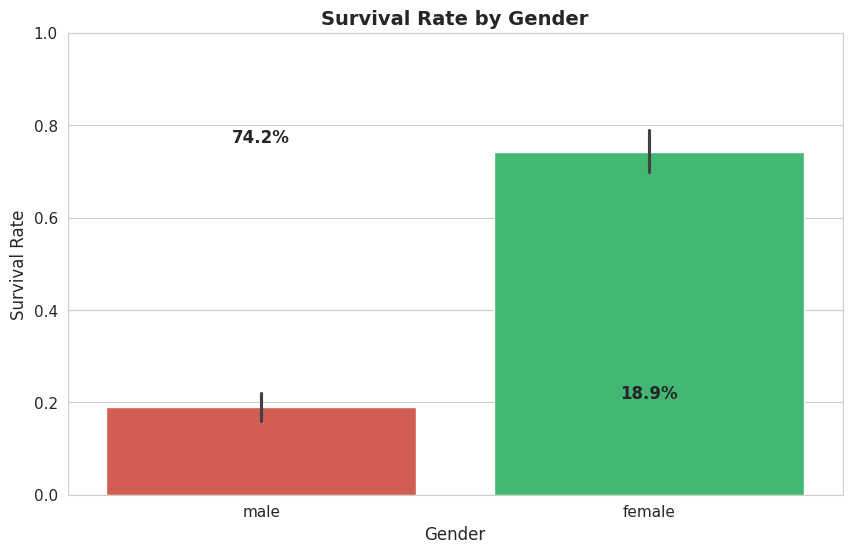

📈 Chart shows females had much higher survival rate!


In [21]:
# Bar chart of survival by gender (from your internship sample)
sns.barplot(x="sex", y="survived", data=df_clean, palette=['#e74c3c', '#2ecc71'])

plt.title('Survival Rate by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.ylim(0, 1)

# Add percentage labels
for i, v in enumerate(df_clean.groupby('sex')['survived'].mean()):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')

plt.show()
print("📈 Chart shows females had much higher survival rate!")

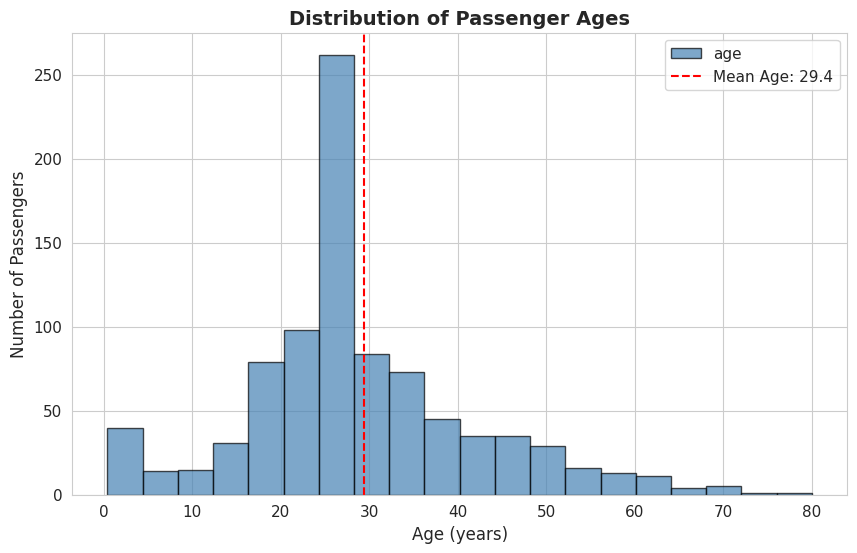

 Most passengers were between 20-40 years old. Mean age: 29.4


In [22]:
# Histogram of ages (from your internship sample)
df_clean['age'].plot(kind='hist', bins=20, color='steelblue', edgecolor='black', alpha=0.7)

plt.title('Distribution of Passenger Ages', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# Add mean line
plt.axvline(df_clean['age'].mean(), color='red', linestyle='--',
            label=f'Mean Age: {df_clean["age"].mean():.1f}')
plt.legend()

plt.show()
print(f" Most passengers were between 20-40 years old. Mean age: {df_clean['age'].mean():.1f}")

In [23]:
# Create age groups
def age_group(age):
    if age < 13:
        return 'Child (0-12)'
    elif age < 20:
        return 'Teen (13-19)'
    elif age < 35:
        return 'Young Adult (20-34)'
    elif age < 50:
        return 'Adult (35-49)'
    elif age < 65:
        return 'Middle Age (50-64)'
    else:
        return 'Senior (65+)'

df_clean['age_group'] = df_clean['age'].apply(age_group)

# Calculate survival by age group
age_survival = df_clean.groupby('age_group')['survived'].mean()
print("Survival Rate by Age Group:")
print(age_survival.sort_values(ascending=False))

Survival Rate by Age Group:
age_group
Child (0-12)           0.579710
Adult (35-49)          0.416149
Middle Age (50-64)     0.412698
Teen (13-19)           0.410526
Young Adult (20-34)    0.343496
Senior (65+)           0.090909
Name: survived, dtype: float64


/tmp/ipykernel_4669/1287848444.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='survived', data=df_clean, order=order, palette='viridis')


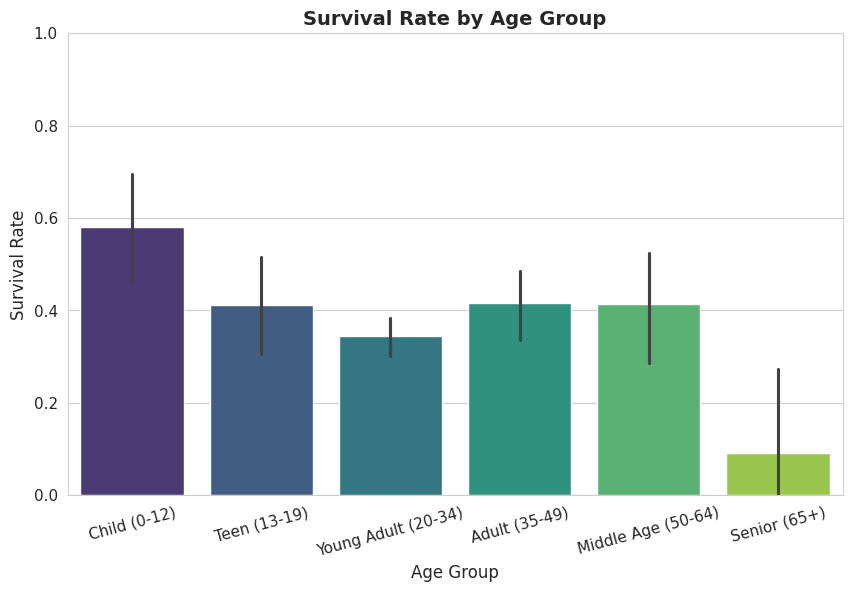

 Children had the highest survival rate - 'Women and Children First' policy!


In [24]:
# Plot survival rate by age group
order = ['Child (0-12)', 'Teen (13-19)', 'Young Adult (20-34)',
         'Adult (35-49)', 'Middle Age (50-64)', 'Senior (65+)']

sns.barplot(x='age_group', y='survived', data=df_clean, order=order, palette='viridis')

plt.title('Survival Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.xticks(rotation=15)
plt.ylim(0, 1)

plt.show()
print(" Children had the highest survival rate - 'Women and Children First' policy!")

In [25]:
print("=" * 55)
print(" TITANIC SURVIVAL ANALYSIS - SUMMARY")
print("=" * 55)

print(f"""
 DATASET: {df_clean.shape[0]} passengers, {df_clean.shape[1]} features

 KEY FINDINGS:

1 GENDER:
   • Female Survival: {df_clean[df_clean['sex']=='female']['survived'].mean():.2%}
   • Male Survival: {df_clean[df_clean['sex']=='male']['survived'].mean():.2%}
   → Women were prioritized for rescue!

2️ PASSENGER CLASS:
   • 1st Class: {df_clean[df_clean['pclass']==1]['survived'].mean():.2%}
   • 2nd Class: {df_clean[df_clean['pclass']==2]['survived'].mean():.2%}
   • 3rd Class: {df_clean[df_clean['pclass']==3]['survived'].mean():.2%}
   → Higher class = Better survival chances!

3️ AGE:
   • Children survived more than adults
   • Mean age: {df_clean['age'].mean():.1f} years

 CONCLUSION:
   Survival depended heavily on GENDER, CLASS, and AGE.
   "Women and Children First" policy is clearly visible in the data.
""")

print("=" * 55)
print(" TASK 2 COMPLETED!")
print("=" * 55)

 TITANIC SURVIVAL ANALYSIS - SUMMARY

 DATASET: 891 passengers, 16 features

 KEY FINDINGS:

1 GENDER:
   • Female Survival: 74.20%
   • Male Survival: 18.89%
   → Women were prioritized for rescue!

2️ PASSENGER CLASS:
   • 1st Class: 62.96%
   • 2nd Class: 47.28%
   • 3rd Class: 24.24%
   → Higher class = Better survival chances!

3️ AGE:
   • Children survived more than adults
   • Mean age: 29.4 years

 CONCLUSION:
   Survival depended heavily on GENDER, CLASS, and AGE.
   "Women and Children First" policy is clearly visible in the data.

 TASK 2 COMPLETED!
